# MSD RecSys — pipeline notebook

End-to-end driver for the Million Song Dataset two-stage recommender.
The library lives in `msd_recsys/`; this notebook just stitches the stages together
and prints diagnostics between them.

**Stages**
1. Setup (install, mount Drive, set paths)
2. Load + filter + split data
3. Stage 1 — retrieval (ALS + semantic IDs -> hybrid pool)
4. Stage 2 — features + ranker
5. Evaluation (overall + bucketed)
6. Submission


## 1. Setup


In [13]:
# --- Colab-only: clone fresh + install. Safe to re-run. ---
import os
os.chdir('/content')                    # so we're not inside the dir we're about to delete
!rm -rf ECS172-Final-Project
!git clone https://github.com/andrewscoding2018/ECS172-Final-Project.git
%cd ECS172-Final-Project
!pip install -q -e ./final_project

# --- Mount Drive for checkpoints (no-op if already mounted) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("not in Colab — running locally")

Cloning into 'ECS172-Final-Project'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 50 (delta 17), reused 38 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 29.78 MiB | 24.71 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/ECS172-Final-Project
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for msd_recsys (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# !pip uninstall -y implicit
# !pip install --no-cache-dir --no-binary=implicit implicit

In [15]:
# from implicit.gpu import HAS_CUDA
# print(f"HAS_CUDA: {HAS_CUDA}")

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd

from msd_recsys import data, retrieval, features, ranker, eval as ev, diagnostics as diag
from msd_recsys.checkpoint import checkpoint, set_checkpoint_dir, list_checkpoints

# Adjust these for your environment.
if IN_COLAB:
    DATA_DIR = Path('/content/drive/MyDrive/ECS 172')
    CKPT_DIR = Path('/content/drive/MyDrive/ECS 172/msd_checkpoints')
else:
    DATA_DIR = Path('./data')
    CKPT_DIR = Path('./checkpoints')

CKPT_DIR.mkdir(parents=True, exist_ok=True)
set_checkpoint_dir(CKPT_DIR)
print(f"DATA_DIR = {DATA_DIR}")
print(f"CKPT_DIR = {CKPT_DIR}")
print(f"existing checkpoints: {list_checkpoints()}")


DATA_DIR = /content/drive/MyDrive/ECS 172
CKPT_DIR = /content/drive/MyDrive/ECS 172/msd_checkpoints
existing checkpoints: [('als_f64_r0.01_i30', 218.945811), ('als_topk_v_1500', 1200.000218), ('als_topk_v_4000', 3200.000218), ('interactions_filtered_s50_u20', 737.875302), ('interactions_raw_v1', 944.950125), ('metadata_v1', 155.779752), ('sid_metadata_v1', 8.445439), ('sid_topk_v_1500', 1200.000218), ('sid_topk_v_1500_n5000', 60.000214), ('sid_topk_v_4000', 3200.000218), ('split_n5', 737.875737), ('ui_matrix_v1', 324.223309)]


## 2. Load + filter + split


In [17]:
from pathlib import Path
DATA_DIR = Path('/content/drive/MyDrive/ECS 172')

for p in sorted(DATA_DIR.iterdir()):
    print(f"  {p.name:50s}  {p.stat().st_size / 1e6:>10.1f} MB")

  Andrew_Kuang_ECS_172_Assignment_1.gdoc                     0.0 MB
  Assignment 3 Report.gdoc                                   0.0 MB
  ECS172 Final Presentation.gslides                          0.0 MB
  MSDChallengeGettingstarted.pdf                             0.2 MB
  kaggle_songs.txt                                           9.9 MB
  kaggle_users.txt                                           4.5 MB
  kaggle_visible_evaluation_triplets.txt                    90.0 MB
  kaggle_visible_evaluation_triplets.zip                    18.4 MB
  msd_checkpoints                                            0.0 MB
  msdchallenge.zip                                          31.2 MB
  taste_profile_song_to_tracks.txt                          14.6 MB
  taste_profile_song_to_tracks.txt.zip                       6.3 MB
  track_metadata.db                                        746.2 MB
  train_triplets (1).txt                                  3001.7 MB
  train_triplets.txt                            

In [18]:
# --- Big files: training interactions + metadata DB ---
interactions = checkpoint(
    "interactions_raw_v1",
    lambda: data.load_triplets(DATA_DIR / "train_triplets.txt"),
)
metadata = checkpoint(
    "metadata_v1",
    lambda: data.load_track_metadata(DATA_DIR / "track_metadata.db"),
)

# --- Canonical Kaggle files (small, no need to checkpoint) ---
# kaggle_songs.txt:                     canonical catalog (~386K song IDs)
# kaggle_users.txt:                     canonical user list (~110K user IDs we must predict for)
# kaggle_visible_evaluation_triplets:   visible half of the eval users' history (~1.45M rows)
canonical_songs = data.load_song_id_list(DATA_DIR / "kaggle_songs.txt")
canonical_users = data.load_user_list(DATA_DIR / "kaggle_users.txt")
visible_eval    = data.load_triplets(DATA_DIR / "kaggle_visible_evaluation_triplets.txt")

# taste_profile_song_to_tracks.txt is not strictly required — triplets and
# metadata.db both key on song_id, so we can join directly. Load it only if you
# have it (e.g., for cross-checking against per-track MSD audio files later).
song_to_track = None
if (DATA_DIR / "taste_profile_song_to_tracks.txt").exists():
    song_to_track = data.load_song_to_track(DATA_DIR / "taste_profile_song_to_tracks.txt")

print(f"interactions (train):    {interactions.shape}")
print(f"metadata:                {metadata.shape}")
print(f"canonical songs:         {len(canonical_songs):,}")
print(f"canonical users:         {len(canonical_users):,}")
print(f"visible eval triplets:   {visible_eval.shape}")
if song_to_track is not None:
    print(f"song-to-track mapping:   {song_to_track.shape}")
diag.diag_data(interactions, items_catalog=metadata)


[ckpt] loading interactions_raw_v1  (945.0 MB)
[ckpt] loading metadata_v1  (155.8 MB)
interactions (train):    (48373586, 3)
metadata:                (1000000, 10)
canonical songs:         386,213
canonical users:         110,000
visible eval triplets:   (1450933, 3)
song-to-track mapping:   (384541, 2)
[diag] interactions: 48,373,586 rows, 1,019,318 users, 384,546 items
[diag] catalog: 1,000,000 items, 61.5% are cold (no train interactions)
       -> any cold-item recall comes from the content/semantic-ID route.
[diag] user history: median=27, p90=105, max=4400
[diag] song popularity: median=13, mean=125.8, max=110479
       -> long-tailed; aggressive item filtering will reshape the distribution.


## 2.5 EDA — preliminary results for the report

These cells produce figures and tables you can paste straight into `report.pdf`.
All figures save to `FIGURE_DIR` (Drive on Colab, `./figures/` locally) and also
display inline.


In [19]:
# === EDA setup: matplotlib defaults + figure output path ===
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

FIGURE_DIR = (Path('/content/drive/MyDrive/msd_figures')
              if IN_COLAB else Path('./figures'))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"figures save to: {FIGURE_DIR}")


figures save to: /content/drive/MyDrive/msd_figures


In [20]:
# === EDA 1/5: dataset-at-a-glance summary table ===
n_interactions = len(interactions)
n_users        = interactions.user_id.nunique()
n_items_train  = interactions.song_id.nunique()
n_items_full   = len(metadata)
cold_share     = 1 - n_items_train / n_items_full

summary = pd.DataFrame([
    ("Interactions (train_triplets.txt)",     f"{n_interactions:,}"),
    ("Unique users in train",                  f"{n_users:,}"),
    ("Unique songs in train",                  f"{n_items_train:,}"),
    ("Songs in full catalog (metadata)",       f"{n_items_full:,}"),
    ("Cold-catalog share (no train listens)",  f"{cold_share:.1%}"),
    ("Mean listens / user",                    f"{n_interactions / n_users:.1f}"),
    ("Mean users / song (train items)",        f"{n_interactions / n_items_train:.1f}"),
    ("Canonical user list (kaggle_users)",     f"{len(canonical_users):,}"),
    ("Canonical song list (kaggle_songs)",     f"{len(canonical_songs):,}"),
], columns=["Statistic", "Value"])
print(summary.to_string(index=False))


                            Statistic      Value
    Interactions (train_triplets.txt) 48,373,586
                Unique users in train  1,019,318
                Unique songs in train    384,546
     Songs in full catalog (metadata)  1,000,000
Cold-catalog share (no train listens)      61.5%
                  Mean listens / user       47.5
      Mean users / song (train items)      125.8
   Canonical user list (kaggle_users)    110,000
   Canonical song list (kaggle_songs)    386,213


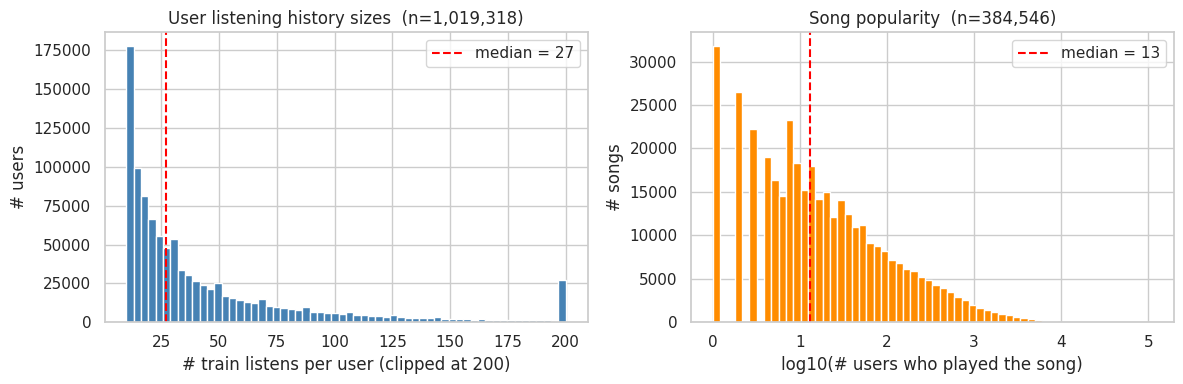


User history sizes:
  median=27  p90=105  p99=284  max=4400
Song popularity:
  median=13  p90=218  p99=1970  max=110479


In [21]:
# === EDA 2/5: user history + song popularity distributions ===
hist_sizes = interactions.groupby("user_id").size()
pop_counts = interactions.groupby("song_id").size()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(hist_sizes.clip(upper=200), bins=60, color="steelblue", edgecolor="white")
ax[0].axvline(hist_sizes.median(), color="red", ls="--",
              label=f"median = {hist_sizes.median():.0f}")
ax[0].set(xlabel="# train listens per user (clipped at 200)",
          ylabel="# users",
          title=f"User listening history sizes  (n={n_users:,})")
ax[0].legend()

ax[1].hist(np.log10(pop_counts), bins=60, color="darkorange", edgecolor="white")
ax[1].axvline(np.log10(pop_counts.median()), color="red", ls="--",
              label=f"median = {pop_counts.median():.0f}")
ax[1].set(xlabel="log10(# users who played the song)",
          ylabel="# songs",
          title=f"Song popularity  (n={n_items_train:,})")
ax[1].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig1_distributions.png")
plt.show()

print(f"\nUser history sizes:")
print(f"  median={hist_sizes.median():.0f}  p90={hist_sizes.quantile(0.9):.0f}  "
      f"p99={hist_sizes.quantile(0.99):.0f}  max={hist_sizes.max()}")
print(f"Song popularity:")
print(f"  median={pop_counts.median():.0f}  p90={pop_counts.quantile(0.9):.0f}  "
      f"p99={pop_counts.quantile(0.99):.0f}  max={pop_counts.max()}")


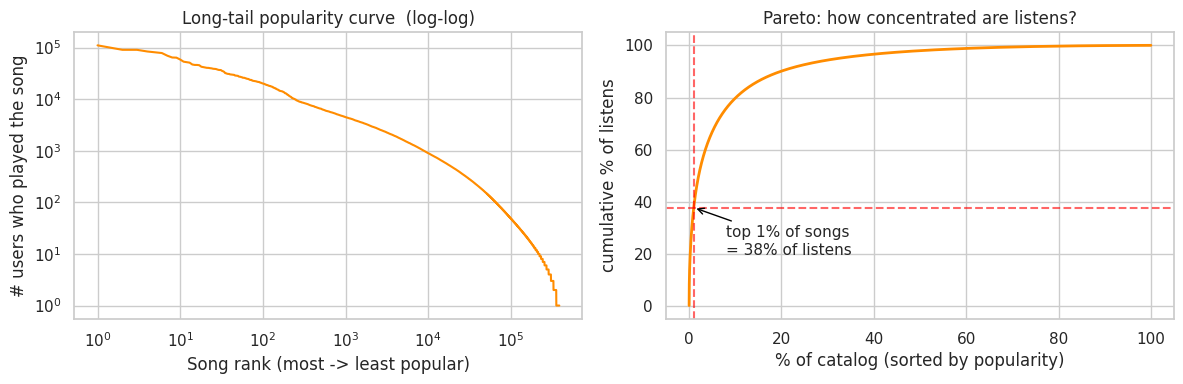

Top-X% of songs account for Y% of listens (motivates the diversity story):
  top   1%  ->   37.8% of listens
  top   5%  ->   66.8% of listens
  top  10%  ->   79.8% of listens
  top  25%  ->   92.6% of listens
  top  50%  ->   98.0% of listens


In [22]:
# === EDA 3/5: long-tail / Pareto popularity curve (headline figure) ===
sorted_pop = pop_counts.sort_values(ascending=False).values
cum_share  = np.cumsum(sorted_pop) / sorted_pop.sum()
rank       = np.arange(1, len(sorted_pop) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left: log-log rank vs listens (the classic long-tail shape)
ax[0].plot(rank, sorted_pop, color="darkorange", linewidth=1.5)
ax[0].set(xscale="log", yscale="log",
          xlabel="Song rank (most -> least popular)",
          ylabel="# users who played the song",
          title="Long-tail popularity curve  (log-log)")

# Right: Pareto cumulative share — "top X% = Y% of listens"
ax[1].plot(rank / len(rank) * 100, cum_share * 100,
           color="darkorange", linewidth=2)
top1_idx = int(0.01 * len(sorted_pop))
top1_pct = cum_share[top1_idx] * 100
ax[1].axvline(1, color="red", ls="--", alpha=0.6)
ax[1].axhline(top1_pct, color="red", ls="--", alpha=0.6)
ax[1].annotate(f"top 1% of songs\n= {top1_pct:.0f}% of listens",
               xy=(1, top1_pct), xytext=(8, top1_pct - 18),
               arrowprops=dict(arrowstyle="->", color="black"),
               fontsize=11)
ax[1].set(xlabel="% of catalog (sorted by popularity)",
          ylabel="cumulative % of listens",
          title="Pareto: how concentrated are listens?")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig2_longtail.png")
plt.show()

print("Top-X% of songs account for Y% of listens (motivates the diversity story):")
for pct in [1, 5, 10, 25, 50]:
    idx = max(int(pct/100 * len(sorted_pop)) - 1, 0)
    print(f"  top {pct:>3}%  ->  {cum_share[idx] * 100:>5.1f}% of listens")


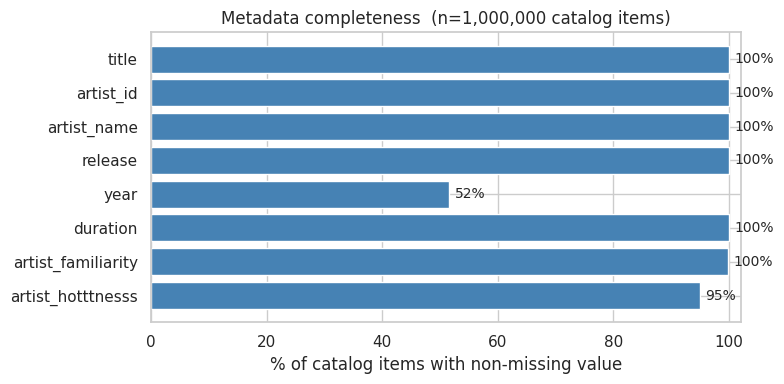

In [23]:
# === EDA 4/5: metadata completeness — justifies 'decade + unknown bucket' design ===
fields = ["title", "artist_id", "artist_name", "release",
          "year", "duration", "artist_familiarity", "artist_hotttnesss"]
fields = [f for f in fields if f in metadata.columns]
completeness = {f: metadata[f].notna().mean() * 100 for f in fields}

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(completeness))
ax.barh(y_pos, list(completeness.values()),
        color="steelblue", edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(list(completeness.keys()))
ax.invert_yaxis()
ax.set_xlim(0, 102)
ax.set_xlabel("% of catalog items with non-missing value")
ax.set_title(f"Metadata completeness  (n={len(metadata):,} catalog items)")
for i, v in enumerate(completeness.values()):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig3_metadata_completeness.png")
plt.show()


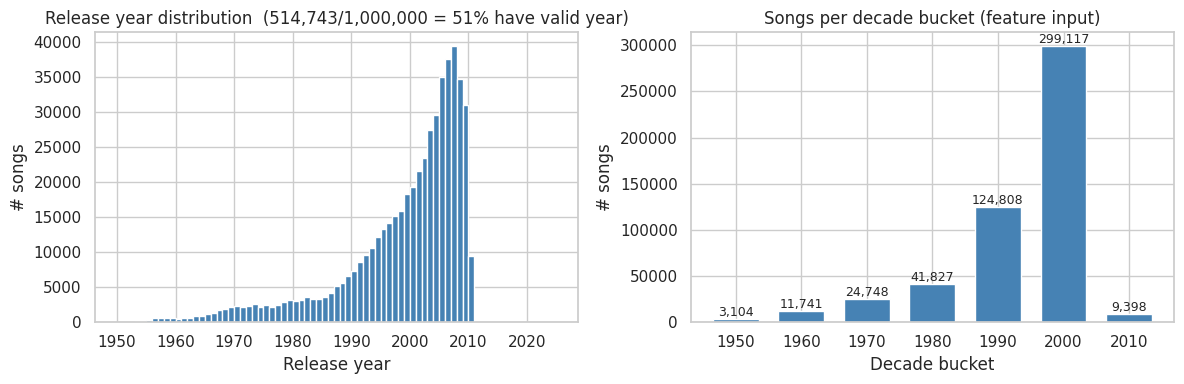

missing or zero year: 484,424 / 1,000,000 (48%) — these get an 'unknown' decade bucket


In [24]:
# === EDA 5/5: release year + decade distribution ===
year = metadata["year"].dropna()
year = year[(year >= 1950) & (year <= 2025)]  # drop obvious garbage

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Per-year histogram
ax[0].hist(year, bins=np.arange(1950, 2026, 1),
           color="steelblue", edgecolor="white")
ax[0].set(xlabel="Release year",
          ylabel="# songs",
          title=f"Release year distribution  "
                f"({len(year):,}/{len(metadata):,} = "
                f"{len(year)/len(metadata):.0%} have valid year)")

# Per-decade bars (this is the actual feature we use)
decade = (metadata["year"].dropna() // 10 * 10).astype(int)
decade = decade[(decade >= 1950) & (decade <= 2020)]
counts = decade.value_counts().sort_index()
ax[1].bar(counts.index.astype(str), counts.values,
          color="steelblue", edgecolor="white", width=0.7)
for i, (d, c) in enumerate(counts.items()):
    ax[1].text(i, c, f"{c:,}", ha="center", va="bottom", fontsize=9)
ax[1].set(xlabel="Decade bucket",
          ylabel="# songs",
          title="Songs per decade bucket (feature input)")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig4_year_decade.png")
plt.show()

missing_year = metadata["year"].isna().sum() + (metadata["year"] == 0).sum()
print(f"missing or zero year: {missing_year:,} / {len(metadata):,} "
      f"({missing_year/len(metadata):.0%}) — these get an 'unknown' decade bucket")


In [25]:
# --- Aggressive filter: drop tail items and low-activity users ---
MIN_SONG_LISTENS = 50
MIN_USER_LISTENS = 20

filtered = checkpoint(
    f"interactions_filtered_s{MIN_SONG_LISTENS}_u{MIN_USER_LISTENS}",
    lambda: data.filter_interactions(
        interactions,
        min_song_listens=MIN_SONG_LISTENS,
        min_user_listens=MIN_USER_LISTENS,
    ),
)
diag.diag_filter(interactions, filtered)


[ckpt] loading interactions_filtered_s50_u20  (737.9 MB)
[diag] after filter:
  rows:    48,373,586 ->   39,327,173  (81.3% kept)
  users:    1,019,318 ->      624,994  (61.3% kept)
  items:      384,546 ->       91,296  (23.7% kept)
       -> tail items dropped; ALS now operates on a denser, more reliable signal.


In [26]:
# --- Hold-out split mirroring the MSD challenge format ---
KEEP_LAST_N = 5
train_inner, valid = checkpoint(
    f"split_n{KEEP_LAST_N}",
    lambda: data.holdout_split(filtered, n_per_user=KEEP_LAST_N),
)
print(f"train_inner: {len(train_inner):,} rows, {train_inner.user_id.nunique():,} users")
print(f"valid      : {len(valid):,} rows,    {valid.user_id.nunique():,} users")


[ckpt] loading split_n5  (737.9 MB)
train_inner: 36,202,203 rows, 624,994 users
valid      : 3,124,970 rows,    624,994 users


In [27]:
# --- Build sparse user-item matrix for ALS ---
ui_matrix, user_to_ix, item_to_ix = checkpoint(
    "ui_matrix_v1",
    lambda: data.build_user_item_matrix(train_inner, confidence_alpha=40.0),
)

print(f"user-item matrix: {ui_matrix.shape}, nnz={ui_matrix.nnz:,}")


[ckpt] loading ui_matrix_v1  (324.2 MB)
user-item matrix: (624994, 90862), nnz=36,202,203


## 3. Stage 1 — Retrieval


In [28]:
# --- ALS via implicit (GPU-accelerated on A100 if available) ---
als = checkpoint(
    "als_f64_r0.01_i30",
    lambda: retrieval.ALSRetriever(factors=64, regularization=0.01, iterations=30).fit(
        ui_matrix, user_to_ix, item_to_ix,
    ),
)

# Optional sanity check — pass a few well-known song titles in if you have them.
# Build a title lookup from metadata for prettier diagnostic output.
title_by_song = dict(zip(metadata.song_id, metadata.title))
diag.diag_als(als, item_titles=title_by_song)


[ckpt] loading als_f64_r0.01_i30  (218.9 MB)
[diag] ALS similar-item check:
  The Cove:
    sim=0.989  Questions
    sim=0.986  Wrong Turn
    sim=0.985  Rainbow
    sim=0.985  Symbol In My Driveway
    sim=0.984  Supposed To Be
  Nothing from Nothing:
    sim=0.921  Ride Captain Ride
    sim=0.914  Soul Finger
    sim=0.910  Groovin'
    sim=0.909  Will It Go Round In Circles
    sim=0.908  Fiera Callada
  Entre Dos Aguas:
    sim=0.949  Almoraima
    sim=0.947  Cepa Andaluza
    sim=0.935  Mediterranean Sundance / Rio Ancho
    sim=0.931  Guajiras De Lucia
    sim=0.921  Chan Chan (Live)
  -> if similar songs are same artist / same era / same genre, ALS is learning real structure.


In [29]:
# --- Semantic-ID retriever (metadata-only for now; revisit if adding audio) ---
# Filter metadata to the items that appear in our filtered training set so the
# semantic-ID space matches what we recommend over.
items_in_train = set(train_inner.song_id.unique())
metadata_in_train = metadata[metadata.song_id.isin(items_in_train)].copy()

sid = checkpoint(
    "sid_metadata_v1",
    lambda: retrieval.SemanticIDRetriever().fit(metadata_in_train),
)
diag.diag_semantic_codes(sid, item_titles=title_by_song, n_show=8)


[ckpt] loading sid_metadata_v1  (8.4 MB)
[diag] Semantic-ID code distribution:
  Rock-N-Rule                              codes=(49, 133, 164, 0, 0)
  Raspberry Beret (LP Version)             codes=(75, 231, 73, 1, 1)
  All of the same blood                    codes=(90, 16, 202, 0, 2)
  Scream                                   codes=(104, 0, 126, 0, 3)
  Dancing In The Dark                      codes=(175, 122, 233, 0, 4)
  Remember (Walking In The Sand)           codes=(177, 62, 84, 2, 5)
  Lucy Fears the Morning Star              codes=(21, 216, 142, 0, 6)
  Get Along (Feat: Pace Won) (Instrumental codes=(4, 198, 214, 0, 7)
  -> items with overlapping codes should share metadata (decade, artist, popularity tier).


In [30]:
# === CELL A: setup (cheap, instant) ===
TOPK_ALS = 1500
TOPK_SID = 1500

valid_users = sorted(valid.user_id.unique())
valid_users = [u for u in valid_users if u in user_to_ix]
valid_user_indices = np.array([user_to_ix[u] for u in valid_users])
hist_by_user = data.histories_from_df(train_inner)
valid_histories = [hist_by_user.get(u, []) for u in valid_users]
valid_truth = valid.groupby("song_id" if False else "user_id")["song_id"].apply(set).to_dict()

print(f"valid users to retrieve for: {len(valid_users):,}")

valid users to retrieve for: 624,994


In [31]:
# === CELL A: setup + sampling (do sampling here, not later) ===
TOPK_ALS = 1500
TOPK_SID = 1500

valid_users = sorted(valid.user_id.unique())
valid_users = [u for u in valid_users if u in user_to_ix]

# ▼ Apply the cap here, so EVERY downstream cell sees the same N users
MAX_USERS = 50000
valid_users = valid_users[:MAX_USERS]
print(f"capped valid_users at {len(valid_users):,}")

valid_user_indices = np.array([user_to_ix[u] for u in valid_users])
hist_by_user = data.histories_from_df(train_inner)
valid_histories = [hist_by_user.get(u, []) for u in valid_users]
valid_truth = valid.groupby("user_id")["song_id"].apply(set).to_dict()

capped valid_users at 50,000


In [32]:
# === CELL B: ALS retrieval (potentially slow, then cached) ===
als_ids, als_sc = checkpoint(
    f"als_topk_v_{TOPK_ALS}",
    lambda: als.recommend_batch(
        ui_matrix, top_k=TOPK_ALS, user_indices=valid_user_indices,
        verbose=True,
    ),
)

[ckpt] loading als_topk_v_1500  (1200.0 MB)


In [33]:
import psutil
print(f"RAM total:     {psutil.virtual_memory().total/1e9:.1f} GB")
print(f"RAM available: {psutil.virtual_memory().available/1e9:.1f} GB")
print(f"len(valid_users)  = {len(valid_users):,}")
print(f"TOPK_ALS, TOPK_SID = {TOPK_ALS}, {TOPK_SID}")
print(f"len(sid.all_items) = {len(sid.all_items):,}  <- SID catalog size")
print(f"als_ids in memory? {('als_ids' in dir())}  shape={getattr(als_ids, 'shape', '—')}")

RAM total:     54.8 GB
RAM available: 42.9 GB
len(valid_users)  = 50,000
TOPK_ALS, TOPK_SID = 1500, 1500
len(sid.all_items) = 91,461  <- SID catalog size
als_ids in memory? True  shape=(100000, 1500)


In [34]:
# === CELL C: SID retrieval, memory-paranoid version ===
import gc
import time
from tqdm.auto import tqdm

# Hard cap on users to retrieve for, to ensure this finishes.
MAX_USERS = 5000
hist_subset = valid_histories[:MAX_USERS]
print(f"running SID for {len(hist_subset):,} users (capped from {len(valid_histories):,})")

def sid_retrieve_safe():
    n = len(hist_subset)
    # int32 output regardless of library version — way smaller than object dtype.
    ids_out = np.empty((n, TOPK_SID), dtype=np.int32)
    sc_out  = np.empty((n, TOPK_SID), dtype=np.float32)
    CHUNK = 500  # smaller chunk = more iterations, less peak memory

    for s in tqdm(range(0, n, CHUNK), desc="SID batches", unit="batch"):
        e = min(s + CHUNK, n)
        chunk_hist = hist_subset[s:e]
        ids, sc = sid.recommend_for_histories(
            chunk_hist, top_k=TOPK_SID,
            already_owned=[set(h) for h in chunk_hist],
        )
        # If lib still returns object dtype, coerce to int via lookup.
        if ids.dtype == object:
            # Map song_id strings -> indices using the SID retriever's mapping
            lookup = sid._item_to_ix
            ids_int = np.empty(ids.shape, dtype=np.int32)
            for i in range(ids.shape[0]):
                for j in range(ids.shape[1]):
                    v = ids[i, j]
                    ids_int[i, j] = lookup.get(v, -1) if v is not None else -1
            ids = ids_int
        ids_out[s:e] = ids
        sc_out[s:e]  = sc

        # Free intermediates and report
        del ids, sc, chunk_hist
        gc.collect()
        avail = psutil.virtual_memory().available / 1e9
        if avail < 3.0:
            print(f"  ⚠️  only {avail:.1f} GB available — consider lowering TOPK_SID or MAX_USERS")

    return ids_out, sc_out

t = time.time()
sid_ids, sid_sc = checkpoint(f"sid_topk_v_{TOPK_SID}_n{MAX_USERS}", sid_retrieve_safe)
print(f"\nSID done: {time.time() - t:.1f}s  shape={sid_ids.shape}  "
      f"({sid_ids.nbytes / 1e6:.1f} MB)")

running SID for 5,000 users (capped from 50,000)
[ckpt] loading sid_topk_v_1500_n5000  (60.0 MB)

SID done: 1.5s  shape=(5000, 1500)  (30.0 MB)


In [35]:
# === CELL D: hybrid candidate pool (long-format DataFrame) ===
canonical_item_to_ix = {it: i for i, it in enumerate(metadata_in_train.song_id.values)}

# --- Align ALS to the SID user subset --------------------------------------
# SID was capped at MAX_USERS (5000) in Cell C, but ALS ran on the full 50k.
# Both arrays share the valid_users ordering, so slice ALS to the first N rows
# so row i refers to the same user in both. (Otherwise build_candidate_pool
# raises ValueError: shapes disagree on user count.)
N = sid_ids.shape[0]
als_ids_use     = als_ids[:N]
als_sc_use      = als_sc[:N]
valid_users_use = valid_users[:N]
assert als_ids_use.shape[0] == sid_ids.shape[0] == N, "user counts still disagree"
print(f"pooling on {N:,} aligned users")

valid_cands = retrieval.build_candidate_pool(
    als_ids_use, als_sc_use, als.ix_to_item,
    sid_ids, sid_sc, sid.all_items,
    canonical_item_to_ix,
    verbose=True,
)
print(valid_cands.head())

# --- pool diagnostics (use the aligned user count) -------------------------
n_users    = N
n_als_only = ((valid_cands.als_score > 0) & (valid_cands.sid_score == 0)).sum()
n_sid_only = ((valid_cands.als_score == 0) & (valid_cands.sid_score > 0)).sum()
n_both     = ((valid_cands.als_score > 0) & (valid_cands.sid_score > 0)).sum()
total      = len(valid_cands)
print(f"avg pool size : {total / n_users:8.1f}/user")
print(f"ALS only      : {n_als_only / n_users:8.1f}/user ({n_als_only / total:.1%})")
print(f"semantic only : {n_sid_only / n_users:8.1f}/user ({n_sid_only / total:.1%})")
print(f"both routes   : {n_both / n_users:8.1f}/user ({n_both / total:.1%})")

pooling on 5,000 aligned users
[pool] als flat: 7,500,000 rows (90.0 MB)
[pool] sid flat: 7,500,000 rows (90.0 MB)
[pool] hybrid pool: 14,472,461 rows (231.6 MB)  avg 2894.5 candidates/user
   user_idx  item_ix  als_score  sid_score
0         0       54   0.000000       16.0
1         0      181   0.179538        0.0
2         0      196   0.000000       16.0
3         0      223   0.169280        0.0
4         0      312   0.000000       17.0
avg pool size :   2894.5/user
ALS only      :   1394.5/user (48.2%)
semantic only :   1390.1/user (48.0%)
both routes   :    109.9/user (3.8%)


## 4. Stage 2 — Features + ranker


In [36]:
# --- Build item feature table (one-shot, used by every (user, candidate) row) ---
item_pop = train_inner.groupby("song_id").size()
item_table = features.ItemFeatureTable.build(
    metadata=metadata_in_train,
    item_popularity=item_pop,
    
    semantic_codes=sid.item_codes,
)
print(f"item feature table: {len(item_table.item_ids):,} items")


item feature table: 91,461 items


In [37]:
# --- 80/20 split of the POOL's users for ranker fit vs eval ---
# valid_cands is a long-format DataFrame (one row per user-item pair) with a
# user_idx column running 0..N-1, where N = the users ALS+SID were aligned on.
# Split by user_idx (filter rows), not by row position, and remap user_idx to
# 0..k-1 so it stays aligned with the sliced users/histories lists.
N = int(valid_cands["user_idx"].max()) + 1
pool_users = valid_users[:N]
pool_hist  = valid_histories[:N]

rng = np.random.default_rng(42)
perm = rng.permutation(N)
split = int(0.8 * N)
fit_ix, eval_ix = perm[:split], perm[split:]

def split_pool(cands, keep_ix):
    """Keep only keep_ix users and remap their user_idx to a contiguous 0..k-1
    range matching the order of keep_ix (so it aligns with the sliced lists)."""
    keep_ix = np.asarray(keep_ix)
    remap = np.full(N, -1, dtype=np.int64)
    remap[keep_ix] = np.arange(len(keep_ix))          # original user_idx -> new position
    sub = cands[cands["user_idx"].isin(keep_ix)].copy()
    sub["user_idx"] = remap[sub["user_idx"].to_numpy()]
    return sub

fit_users  = [pool_users[i] for i in fit_ix]
fit_hist   = [pool_hist[i]  for i in fit_ix]
fit_cands  = split_pool(valid_cands, fit_ix)

eval_users = [pool_users[i] for i in eval_ix]
eval_hist  = [pool_hist[i]  for i in eval_ix]
eval_cands = split_pool(valid_cands, eval_ix)

X_fit,  y_fit,  k_fit,  g_fit  = features.build_feature_rows(
    fit_users, fit_hist, fit_cands, item_table, truth_by_user=valid_truth,
)
X_eval, y_eval, k_eval, g_eval = features.build_feature_rows(
    eval_users, eval_hist, eval_cands, item_table, truth_by_user=valid_truth,
)

g_fit_nz  = [g for g in g_fit  if g > 0]
g_eval_nz = [g for g in g_eval if g > 0]
print(f"ranker fit : X={X_fit.shape}, positives={int(y_fit.sum()):,} ({y_fit.mean():.2%})")
print(f"ranker eval: X={X_eval.shape}, positives={int(y_eval.sum()):,} ({y_eval.mean():.2%})")
diag.diag_features(X_fit, y_fit, features.FEATURE_NAMES)

ranker fit : X=(11575413, 11), positives=2,027 (0.02%)
ranker eval: X=(2897048, 11), positives=471 (0.02%)
[diag] feature means by class (discriminative power):
  feature                       positive      negative     ratio
  hist_size_log                   3.5116        3.7772     0.93x
  distinct_artists_log            3.1078        3.2879     0.95x
  avg_artist_familiarity          0.7501        0.7383     1.02x
  pop_log                         7.9333        6.4192     1.24x
  artist_familiarity              0.7980        0.7538     1.06x
  artist_hotttnesss               0.6426        0.5613     1.14x
  decade                       1706.2629     1753.9009     0.97x
  als_score                       0.2712        0.1620     1.67x
  semantic_score                 14.5017       21.1273     0.69x
  shared_artists                  0.4312        0.0233    18.52x
  semantic_match_count            1.0612        0.6687     1.59x
  -> ratios far from 1.0 mean the feature separates the cla

In [38]:
# --- Train LightGBM lambdarank ---
model = ranker.train_lambdarank(
    X_fit, y_fit, group_sizes=g_fit_nz,
    eval_set=(X_eval, y_eval), eval_group=g_eval_nz,
    n_estimators=300, max_position=500, early_stopping_rounds=20,
)
diag.diag_permutation_importance(model, X_eval, y_eval, features.FEATURE_NAMES, rng=rng)


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Training until validation scores don't improve for 20 rounds
[50]	valid_0's map@10: 0.717976	valid_0's map@100: 0.723389	valid_0's map@500: 0.723733
Early stopping, best iteration is:
[47]	valid_0's map@10: 0.719279	valid_0's map@100: 0.72453	valid_0's map@500: 0.724902


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with fea

[diag] permutation importance (sampled 30K eval rows, AP scoring):
  feature                   importance       std
  shared_artists               0.01893   0.00022
  semantic_match_count         0.00797   0.00068
  distinct_artists_log         0.00448   0.00337
  decade                       0.00369   0.00082
  artist_familiarity           0.00304   0.00227
  artist_hotttnesss            0.00243   0.00214
  avg_artist_familiarity       0.00033   0.00175
  semantic_score               0.00010   0.00257
  als_score                   -0.00517   0.00089
  pop_log                     -0.00870   0.02258
  hist_size_log               -0.01737   0.01200
  -> drop in AP when feature is shuffled; higher = ranker relies on it more.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with fea

## 5. Evaluation


In [39]:
# --- Rank candidates -> top-500 per user, compute metrics ---
eval_owned = {u: set(h) for u, h in zip(eval_users, eval_hist)}
eval_truth = {u: valid_truth[u] for u in eval_users if u in valid_truth}
item_ids_arr = np.asarray(item_table.item_ids, dtype=object)

ranked = ranker.rank_candidates(
    model, X_eval, k_eval,
    users=eval_users, item_ids=item_table.item_ids,
    top_k=500, exclude_owned=eval_owned,
)

map500    = ev.map_at_k(ranked,         eval_truth, k=500)
recall500 = ev.mean_recall_at_k(ranked, eval_truth, k=500)
ndcg500   = ev.mean_ndcg_at_k(ranked,   eval_truth, k=500)

# Retrieval ceiling on the eval slice — build per-user candidate song_id sets
# from the long-format pool (user_idx -> eval_users, item_ix -> song_id).
cand_sets = {
    eval_users[int(uix)]: set(item_ids_arr[grp["item_ix"].to_numpy()].tolist())
    for uix, grp in eval_cands.groupby("user_idx", sort=True)
}
ret_recall = ev.retrieval_recall(cand_sets, eval_truth)

# Sum-of-scores baseline — score = als_score + semantic_score, then top-500
# per user with the same owned-exclusion logic as the ranker.
baseline_scores = (
    X_eval[:, features.FEATURE_NAMES.index("als_score")]
    + X_eval[:, features.FEATURE_NAMES.index("semantic_score")]
)
bdf = k_eval.copy()
bdf["score"] = baseline_scores
bdf = bdf.sort_values(["user_idx", "score"], ascending=[True, False], kind="stable")

baseline_ranked: dict = {}
for uix, grp in bdf.groupby("user_idx", sort=True):
    u = eval_users[int(uix)]
    owned = eval_owned.get(u, set())
    picks = []
    for ix in grp["item_ix"].to_numpy():
        song_id = item_ids_arr[ix]
        if song_id in owned:
            continue
        picks.append(song_id)
        if len(picks) == 500:
            break
    baseline_ranked[u] = picks

baseline_map500 = ev.map_at_k(baseline_ranked, eval_truth, k=500)

print(f"MAP@500     : {map500:.4f}")
print(f"Recall@500  : {recall500:.4f}")
print(f"NDCG@500    : {ndcg500:.4f}")
print(f"baseline MAP@500 (als+sid sum): {baseline_map500:.4f}")
diag.diag_results(map_score=map500, retrieval_recall=ret_recall, baseline_map=baseline_map500)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


MAP@500     : 0.0169
Recall@500  : 0.0766
NDCG@500    : 0.0439
baseline MAP@500 (als+sid sum): 0.0001
[diag] putting it together:
  Retrieval ceiling (Recall@pool) : 0.0926
  Achieved MAP@500              : 0.0169
  Capture efficiency              : 18.2%
  Lift over baseline              : 168.42x
  -> if capture efficiency is low, ranker is the bottleneck; if ceiling is low, retrieval is.


In [40]:
# --- Bucketed evaluation: by user history size ---
user_hist_size = {u: len(h) for u, h in zip(eval_users, eval_hist)}
def history_bucket(n):
    if n < 30:   return "0_light"     # leading underscores for sort order
    if n < 100:  return "1_medium"
    return "2_heavy"
user_buckets = {u: history_bucket(n) for u, n in user_hist_size.items()}

bucketed = ev.metrics_by_bucket(ranked, {u: valid_truth[u] for u in eval_users}, user_buckets, k=500)
print("by user-history bucket:")
print(bucketed.to_string(index=False))


by user-history bucket:
  bucket  users  MAP@500  Recall@500  NDCG@500
 0_light    381 0.023411    0.102362  0.059579
1_medium    446 0.014613    0.070852  0.039433
 2_heavy    173 0.008400    0.034682  0.020963


In [ ]:
# --- Catalog coverage + tail-focused MAP ---
catalog_size = len(item_table.item_ids)
coverage = ev.catalog_coverage(ranked, catalog_size, k=500)
print(f"catalog coverage @500: {coverage:.2%}  ({int(coverage * catalog_size):,} of {catalog_size:,} items recommended to >=1 user)")

# Popularity tiers (head/torso/tail by cumulative listen share)
item_tier = ev.popularity_tiers(item_pop)
tail_map = ev.tail_focused_map(ranked, {u: valid_truth[u] for u in eval_users}, item_tier, k=500, tier="tail")
torso_map = ev.tail_focused_map(ranked, {u: valid_truth[u] for u in eval_users}, item_tier, k=500, tier="torso")
head_map = ev.tail_focused_map(ranked, {u: valid_truth[u] for u in eval_users}, item_tier, k=500, tier="head")
print(f"\nMAP@500 by ground-truth popularity tier:")
print(f"  head : {head_map:.4f}")
print(f"  torso: {torso_map:.4f}")
print(f"  tail : {tail_map:.4f}")
print("  -> the tail number is the 'discovery' signal — does the system help users find long-tail songs they actually played?")


catalog coverage @500: 25.53%  (23,349 of 91,461 items recommended to >=1 user)

MAP@500 by ground-truth popularity tier:
  head : 0.0659
  torso: 0.0056
  tail : 0.0056
  -> the tail number is the 'discovery' signal — does the system help users find long-tail songs they actually played?


In [42]:
truth_items = set()
for u in valid_users:
    truth_items |= valid_truth.get(u, set())

train_items = set(train_inner.song_id.unique())
sid_items   = set(sid.all_items)

print(f"unique held-out items     : {len(truth_items):,}")
print(f"  also scorable by ALS    : {len(truth_items & train_items):,}  ({len(truth_items & train_items)/len(truth_items):.1%})")
print(f"  also scorable by SID    : {len(truth_items & sid_items):,}  ({len(truth_items & sid_items)/len(truth_items):.1%})")
print(f"  unreachable by EITHER   : {len(truth_items - train_items - sid_items):,}  ({len(truth_items - train_items - sid_items)/len(truth_items):.1%})")

unique held-out items     : 21,400
  also scorable by ALS    : 20,968  (98.0%)
  also scorable by SID    : 20,968  (98.0%)
  unreachable by EITHER   : 432  (2.0%)


In [43]:
hist_sizes = pd.Series([len(h) for h in valid_histories])
print(f"valid history sizes (after last-5 holdout):")
print(f"  min/p25/median/p75/max: {hist_sizes.min()} / {hist_sizes.quantile(.25):.0f} / {hist_sizes.median():.0f} / {hist_sizes.quantile(.75):.0f} / {hist_sizes.max()}")
print(f"  users with ≤5 listens : {(hist_sizes <= 5).sum():,} ({(hist_sizes <= 5).mean():.0%})")

valid history sizes (after last-5 holdout):
  min/p25/median/p75/max: 15 / 23 / 37 / 70 / 1383
  users with ≤5 listens : 0 (0%)


In [44]:
pop = train_inner.groupby("song_id").size().sort_values(ascending=False)
pop_top = pop.head(2000).index.tolist()  # match your ~1922 pool size

# How many held-out hits would top-2000-by-popularity catch?
pop_set = set(pop_top)
hits = total = 0
for u, t in valid_truth.items():
    if u not in set(valid_users):
        continue
    if not t:
        continue
    hits += len(t & pop_set)
    total += len(t)
print(f"popularity-baseline recall@2000: {hits/total:.4f}")

KeyboardInterrupt: 

## 5b. Official MSD Challenge evaluation (leaderboard-comparable)

Section 5 scores a **synthetic** split (`last-5` holdout + 80/20 user slice) over a
**filtered** catalog inside a bounded retrieval pool — great for diagnosis, but the
absolute MAP@500 is **not** comparable to the published leaderboard.

This section uses the **real challenge split** so the number *is* comparable:

| | Section 5 (diagnostic) | Section 5b (official) |
|---|---|---|
| Eval truth | last-5 holdout we invented | `year1_test_triplets_hidden` |
| User profile | `train_inner` history | `year1_test_triplets_visible` |
| Ranker training | 80/20 slice of the eval users | the **valid** users (`year1_valid_*`) |
| Catalog | filtered (>=50 listens) | full `kaggle_songs` catalog |
| Scoring | within the ~3k-candidate pool | full catalog (pool is just an internal speedup) |

**Design.** Train ALS on `train_triplets` + the *visible* halves (so eval users get
factors); train the ranker on the **valid** users; report on the **test** users. No
early-stopping on test -> no leakage.

**Leak guard (important).** `train_triplets.txt` is the *full* Taste Profile and
already contains the eval users' complete histories — including the hidden songs.
Cell 5b.2 drops every eval user from the training interactions and re-adds only
their visible half. Without this the MAP@500 is inflated and meaningless.

**TOPK bump.** Section 5's diagnostic showed ~98% of held-out songs are *reachable*
yet only ~9% land in the top-1500 pool — i.e. retrieval *depth* is the bottleneck.
So 5b.3 uses `TOPK = 3000` (vs 1500). Watch the printed retrieval ceiling: it should
climb well above 0.093.

**Memory.** Higher TOPK + the full test set is heavy. 5b.3 defaults `EVAL_MAX_USERS`
to a 30k-user sample (an unbiased MAP@500 estimate). Set it to `None` for the full
test set only if you have RAM headroom, or lower `TOPK`. Everything is checkpointed.

In [ ]:
# === 5b.1: load the official MSD Challenge eval split (year1 valid + test) ===
valid_visible = data.load_triplets(DATA_DIR / "year1_valid_triplets_visible.txt")
valid_hidden  = data.load_triplets(DATA_DIR / "year1_valid_triplets_hidden.txt")
test_visible  = data.load_triplets(DATA_DIR / "year1_test_triplets_visible.txt")
test_hidden   = data.load_triplets(DATA_DIR / "year1_test_triplets_hidden.txt")

for nm, d in [("valid_visible", valid_visible), ("valid_hidden", valid_hidden),
              ("test_visible", test_visible),   ("test_hidden", test_hidden)]:
    print(f"{nm:14s} {d.shape[0]:>10,} rows  {d.user_id.nunique():>8,} users  {d.song_id.nunique():>8,} songs")

In [ ]:
# === 5b.2: leakage-free training signal + refit Stage 1 on the full catalog ===
# CRITICAL: train_triplets.txt is the FULL Taste Profile and already contains the
# eval users' COMPLETE histories (visible AND hidden). Training on it as-is would
# leak the answers. So we drop every eval user from the training interactions and
# add back ONLY their visible half -> the real challenge setup:
#   non-eval users' full history  +  eval users' visible-only history.
eval_user_set = set(valid_visible.user_id) | set(test_visible.user_id)
n_leak = int(interactions.user_id.isin(eval_user_set).sum())
train_clean  = interactions[~interactions.user_id.isin(eval_user_set)]
train_signal = pd.concat([train_clean, valid_visible, test_visible], ignore_index=True)
print(f"leak guard: dropped {n_leak:,} eval-user rows from train_triplets, "
      f"re-added {len(valid_visible) + len(test_visible):,} visible rows")
print(f"combined ALS signal: {len(train_signal):,} rows, "
      f"{train_signal.user_id.nunique():,} users, {train_signal.song_id.nunique():,} songs")

# Candidate catalog = the official kaggle_songs catalog (one metadata row per song).
# Full-catalog scoring is what makes MAP@500 comparable to the leaderboard.
# NB: parse kaggle_songs.txt via the order-agnostic index map — load_song_id_list
# can mis-split this file (it returns whole lines like "SOxxx 1" when the song_id
# column comes first), which leaves the isin() below empty.
canonical_set = set(data.load_song_index_map(DATA_DIR / "kaggle_songs.txt"))
metadata_off = (metadata[metadata.song_id.isin(canonical_set)]
                .drop_duplicates("song_id").reset_index(drop=True))
assert len(metadata_off) > 0, (
    "metadata_off is empty — song_id mismatch between kaggle_songs.txt and "
    "track_metadata.db. Check the kaggle_songs.txt format / song_id column.")
n_with_md = len(canonical_set & set(metadata.song_id))
print(f"official candidate catalog: {len(metadata_off):,} songs "
      f"({len(canonical_set):,} in kaggle_songs, {n_with_md:,} with metadata)")

# Heavy step: refit ALS on the full unfiltered matrix (keep on GPU). Checkpointed.
ui_off, user_to_ix_off, item_to_ix_off = checkpoint(
    "official_ui_matrix",
    lambda: data.build_user_item_matrix(train_signal, confidence_alpha=40.0),
)
als_off = checkpoint(
    "official_als_f64_r0.01_i30",
    lambda: retrieval.ALSRetriever(factors=64, regularization=0.01, iterations=30).fit(
        ui_off, user_to_ix_off, item_to_ix_off),
)
# SID over the full candidate catalog (metadata-only -> no leakage).
sid_off = checkpoint(
    "official_sid_metadata",
    lambda: retrieval.SemanticIDRetriever().fit(metadata_off),
)

# Item feature table + canonical index space (shared by pool + features + ranker).
canonical_item_to_ix_off = {it: i for i, it in enumerate(metadata_off.song_id.values)}
item_pop_off = train_signal.groupby("song_id").size()   # popularity from leak-free signal
item_table_off = features.ItemFeatureTable.build(
    metadata=metadata_off, item_popularity=item_pop_off, semantic_codes=sid_off.item_codes)
print(f"item feature table: {len(item_table_off.item_ids):,} items | "
      f"SID catalog: {len(sid_off.all_items):,} items")

In [ ]:
# === 5b.3: retrieve + pool for the valid (ranker-train) and test (eval) users ===
TOPK = 3000   # bumped from 1500 -> raises the retrieval ceiling (see 5b header)
known = set(user_to_ix_off)   # users ALS can score (have a row/factors in the matrix)

valid_users_o, valid_hist_o, valid_owned_o, valid_truth_o = data.load_eval_user_inputs(
    valid_visible, valid_hidden, restrict_users_to=known)
test_users_o, test_hist_o, test_owned_o, test_truth_o = data.load_eval_user_inputs(
    test_visible, test_hidden, restrict_users_to=known)

# Default to a 30k-user sample of the test set (unbiased MAP@500 estimate) so the
# higher TOPK doesn't OOM. Set EVAL_MAX_USERS=None for the FULL test set if you have
# RAM headroom; valid is small so it's effectively never capped.
EVAL_MAX_USERS = 30000
if EVAL_MAX_USERS:
    valid_users_o, valid_hist_o = valid_users_o[:EVAL_MAX_USERS], valid_hist_o[:EVAL_MAX_USERS]
    test_users_o,  test_hist_o  = test_users_o[:EVAL_MAX_USERS],  test_hist_o[:EVAL_MAX_USERS]
print(f"valid users (ranker train): {len(valid_users_o):,}")
print(f"test  users (final eval)  : {len(test_users_o):,}")

def retrieve_and_pool(users, histories, owned, *, tag):
    """ALS + SID retrieval -> hybrid candidate pool for one user set.
    pool.user_idx aligns with the `users`/`histories` order passed in."""
    idxs = np.array([user_to_ix_off[u] for u in users])
    als_ids, als_sc = checkpoint(
        f"official_als_topk_{tag}_k{TOPK}_n{len(users)}",
        lambda: als_off.recommend_batch(ui_off, top_k=TOPK, user_indices=idxs, verbose=True))
    sid_ids, sid_sc = checkpoint(
        f"official_sid_topk_{tag}_k{TOPK}_n{len(users)}",
        lambda: sid_off.recommend_for_histories(
            histories, top_k=TOPK, already_owned=[owned[u] for u in users],
            batch=256, verbose=True))
    return retrieval.build_candidate_pool(
        als_ids, als_sc, als_off.ix_to_item, sid_ids, sid_sc, sid_off.all_items,
        canonical_item_to_ix_off, verbose=True)

valid_pool_o = retrieve_and_pool(valid_users_o, valid_hist_o, valid_owned_o, tag="valid")
test_pool_o  = retrieve_and_pool(test_users_o,  test_hist_o,  test_owned_o,  tag="test")

In [ ]:
# === 5b.4: features + train the ranker on the VALID users ===
# Train on valid, evaluate on test -> no synthetic 80/20 split. We deliberately do
# NOT early-stop on test (that would leak test labels into model selection); fixed
# n_estimators keeps test fully held out. Tune n_estimators on valid if desired.
X_tr, y_tr, k_tr, g_tr = features.build_feature_rows(
    valid_users_o, valid_hist_o, valid_pool_o, item_table_off, truth_by_user=valid_truth_o)
X_te, y_te, k_te, g_te = features.build_feature_rows(
    test_users_o, test_hist_o, test_pool_o, item_table_off, truth_by_user=test_truth_o)

g_tr_nz = [g for g in g_tr if g > 0]   # LightGBM group arg can't contain zeros
print(f"ranker train: X={X_tr.shape}, positives={int(y_tr.sum()):,} ({y_tr.mean():.3%})")
print(f"test  matrix: X={X_te.shape}, positives={int(y_te.sum()):,} ({y_te.mean():.3%})")
diag.diag_features(X_tr, y_tr, features.FEATURE_NAMES)

model_off = ranker.train_lambdarank(
    X_tr, y_tr, group_sizes=g_tr_nz,
    n_estimators=300, max_position=500, early_stopping_rounds=None,
)

In [ ]:
# === 5b.5: rank TEST users -> official MAP@500, ceiling, baseline, leaderboard ===
item_ids_off = np.asarray(item_table_off.item_ids, dtype=object)

ranked_o = ranker.rank_candidates(
    model_off, X_te, k_te,
    users=test_users_o, item_ids=item_table_off.item_ids,
    top_k=500, exclude_owned=test_owned_o,
)

map500_o    = ev.map_at_k(ranked_o,         test_truth_o, k=500)
recall500_o = ev.mean_recall_at_k(ranked_o, test_truth_o, k=500)
ndcg500_o   = ev.mean_ndcg_at_k(ranked_o,   test_truth_o, k=500)

# Retrieval ceiling on the official catalog. Unlike Section 5 this is a REAL ceiling,
# not a pooling artifact: hidden songs no retriever can reach cap recall.
cand_sets_o = {
    test_users_o[int(uix)]: set(item_ids_off[grp["item_ix"].to_numpy()].tolist())
    for uix, grp in test_pool_o.groupby("user_idx", sort=True)
}
ceiling_o = ev.retrieval_recall(cand_sets_o, test_truth_o)

# Sum-of-scores baseline (als_score + semantic_score), same owned-exclusion logic.
base_scores = (
    X_te[:, features.FEATURE_NAMES.index("als_score")]
    + X_te[:, features.FEATURE_NAMES.index("semantic_score")]
)
bdf = k_te.copy()
bdf["score"] = base_scores
bdf = bdf.sort_values(["user_idx", "score"], ascending=[True, False], kind="stable")
baseline_o = {}
for uix, grp in bdf.groupby("user_idx", sort=True):
    u = test_users_o[int(uix)]
    owned = test_owned_o.get(u, set())
    picks = []
    for ix in grp["item_ix"].to_numpy():
        s = item_ids_off[ix]
        if s in owned:
            continue
        picks.append(s)
        if len(picks) == 500:
            break
    baseline_o[u] = picks
baseline_map_o = ev.map_at_k(baseline_o, test_truth_o, k=500)

print("=== OFFICIAL MSD CHALLENGE EVALUATION (year1_test, full catalog) ===")
print(f"users scored : {len(test_truth_o):,}  (TOPK={TOPK})")
print(f"MAP@500      : {map500_o:.4f}")
print(f"Recall@500   : {recall500_o:.4f}")
print(f"NDCG@500     : {ndcg500_o:.4f}")
print(f"baseline MAP@500 (als+sid sum): {baseline_map_o:.4f}")
print(f"retrieval ceiling (Recall@pool): {ceiling_o:.4f}  "
      f"-> capture efficiency {ev.capture_efficiency(map500_o, ceiling_o):.1%}")
ev.compare_to_leaderboard(map500_o, k=500)

## 6. Submission


In [ ]:
# === 6.1: generate a leaderboard-format submission for kaggle_users.txt ===
# Reuses the Section-5b official models (als_off, sid_off, item_table_off, model_off,
# canonical_item_to_ix_off, item_pop_off, TOPK). kaggle_users.txt (110k) = the year1
# valid+test users, so they already have ALS factors; their visible history is
# `visible_eval` (Section 2). RUN SECTION 5b FIRST.
#
# Processes users in CHUNKS so the full 110k x TOPK pipeline doesn't OOM. Output =
# MSD Challenge default: one line per user (kaggle order), up to 500 ranked song
# INDICES (1-based, from kaggle_songs.txt), space-separated, best first. Flip
# WRITE_SONG_IDS to emit raw SOxxxx ids instead.
WRITE_SONG_IDS = False
CHUNK_U = 20000
SUBMISSION_PATH = (Path('/content/drive/MyDrive/ECS 172/submission.txt')
                   if IN_COLAB else Path('./submission.txt'))

sub_hist_by_user = data.histories_from_df(visible_eval)
sub_owned = {u: set(h) for u, h in sub_hist_by_user.items()}

sub_users_all = [u for u in canonical_users if u in user_to_ix_off]
n_missing = len(canonical_users) - len(sub_users_all)
print(f"canonical users: {len(canonical_users):,} | rankable via ALS+SID: {len(sub_users_all):,} | "
      f"popularity fallback: {n_missing:,}")

# Rank in chunks (peak memory ~ CHUNK_U users, not 110k).
ranked_sub = {}
for s in range(0, len(sub_users_all), CHUNK_U):
    chunk  = sub_users_all[s:s + CHUNK_U]
    hists  = [sub_hist_by_user.get(u, []) for u in chunk]
    owned  = {u: sub_owned.get(u, set()) for u in chunk}
    idxs   = np.array([user_to_ix_off[u] for u in chunk])
    a_ids, a_sc = als_off.recommend_batch(ui_off, top_k=TOPK, user_indices=idxs)
    s_ids, s_sc = sid_off.recommend_for_histories(
        hists, top_k=TOPK, already_owned=[owned[u] for u in chunk], batch=256)
    pool = retrieval.build_candidate_pool(
        a_ids, a_sc, als_off.ix_to_item, s_ids, s_sc, sid_off.all_items,
        canonical_item_to_ix_off)
    Xc, _, kc, _ = features.build_feature_rows(
        chunk, hists, pool, item_table_off, truth_by_user=None)
    ranked_sub.update(ranker.rank_candidates(
        model_off, Xc, kc, users=chunk, item_ids=item_table_off.item_ids,
        top_k=500, exclude_owned=owned))
    print(f"  ranked {min(s + CHUNK_U, len(sub_users_all)):,}/{len(sub_users_all):,} users")

# Popularity fallback (users with no ALS factors / empty pool).
pop_rank = item_pop_off.sort_values(ascending=False).index.tolist()
def popularity_fill(owned, k=500):
    out = []
    for s in pop_rank:
        if s in owned:
            continue
        out.append(s)
        if len(out) == k:
            break
    return out

song_to_index = data.load_song_index_map(DATA_DIR / "kaggle_songs.txt")
n_written = n_short = 0
with open(SUBMISSION_PATH, "w") as f:
    for u in canonical_users:
        recs = ranked_sub.get(u) or popularity_fill(sub_owned.get(u, set()))
        if WRITE_SONG_IDS:
            line_items = [s for s in recs if s in song_to_index][:500]
        else:
            line_items = [str(song_to_index[s]) for s in recs if s in song_to_index][:500]
        if len(line_items) < 500:
            n_short += 1
        f.write(" ".join(line_items) + "\n")
        n_written += 1

print(f"wrote {n_written:,} user lines -> {SUBMISSION_PATH}")
if n_short:
    print(f"  note: {n_short:,} users have <500 valid recs "
          f"(cold songs missing from kaggle_songs index)")